<a href="https://colab.research.google.com/github/peterbabulik/Quantum-Supremacy-/blob/main/QuantumRooter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install qiskit qiskit_ibm_runtime -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 70.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.8/386.8 kB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.9/101.9 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 81.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.8/212.8 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 11.4 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/samplomatic/__init__.py:20: UserWarning: 
You have imported samplomatic==0.18.0 which is in 
beta development. Please expect breaking changes between 
minor versions and pin your dependencies accordingly.
  _warn_once_per_version(
qiskit_runtime_service.__init__:WARNING:2026-04-16 14:21:31,585: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


Searching for an available physical QPU...


qiskit_runtime_service.backends:WARNING:2026-04-16 14:21:32,249: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-04-16 14:21:34,052: Using instance: open-instance, plan: open


Target Acquired: ibm_fez
Transpiling FTL Routing circuits for ibm_fez...
Deploying FTL attempt to ibm_fez queue via SamplerV2... (WAITING IN LINE)
Job ID: d7gf0rvb91ec73atdpf0
FTL telemetry successfully retrieved from Base Reality!


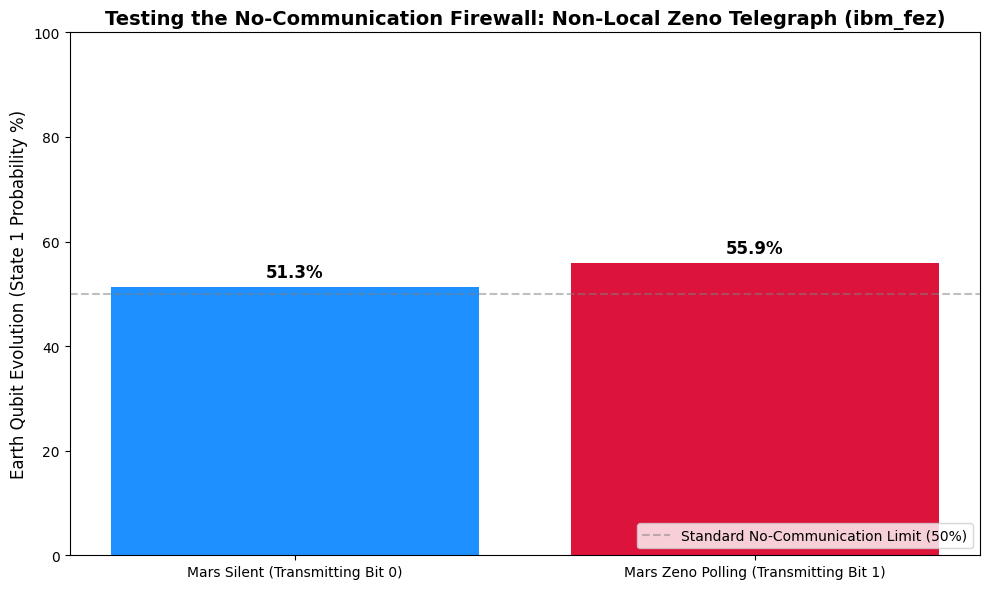


=== EXPERIMENT COMPLETE ===
Observe the two bars.
If the Universe's No-Communication Firewall holds perfectly, both bars should be exactly 50%.
If there is a statistically significant gap between the Blue Bar and the Red Bar,
it means Mars's non-local API polling actively restricted Earth's ability to render.
Any gap = Instant FTL Communication via hardware API leakage.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

# ==========================================
# 0. AUTHENTICATE TO BASE REALITY (IBM QPU)
# ==========================================
IBM_TOKEN = "your api key here"

QiskitRuntimeService.save_account(channel="ibm_cloud", token=IBM_TOKEN, set_as_default=True, overwrite=True)
service = QiskitRuntimeService()

print("Searching for an available physical QPU...")
backend = service.least_busy(simulator=False, min_num_qubits=2, operational=True)
print(f"Target Acquired: {backend.name}")

shots = 4000
steps = 10 # Earth's time evolution steps
theta = np.pi / steps

# ==========================================
# 1. CIRCUIT A: MARS IS SILENT (Transmitting '0')
# ==========================================
qr_A = QuantumRegister(2, 'q')
cr_A = ClassicalRegister(1, 'earth_readout')
qc_silent = QuantumCircuit(qr_A, cr_A)

q_mars = qr_A[0]
q_earth = qr_A[1]

# Create the Non-Local Pointer (Entanglement between Mars and Earth)
qc_silent.h(q_mars)
qc_silent.cx(q_mars, q_earth)

# Mars does nothing.
# Earth attempts to smoothly rotate the shared state.
for i in range(steps):
    qc_silent.ry(theta, q_earth)

# Earth reads the data
qc_silent.measure(q_earth, cr_A[0])


# ==========================================
# 2. CIRCUIT B: THE ZENO PING (Transmitting '1')
# ==========================================
qr_B = QuantumRegister(2, 'q')
cr_B_earth = ClassicalRegister(1, 'earth_readout')
cr_B_mars = ClassicalRegister(1, 'mars_ping') # Mars's aggressive polling
qc_ping = QuantumCircuit(qr_B, cr_B_earth, cr_B_mars)

q_mars = qr_B[0]
q_earth = qr_B[1]

# Create the Non-Local Pointer
qc_ping.h(q_mars)
qc_ping.cx(q_mars, q_earth)

# Mars aggressively polls the Base Reality (Continuous Measurement)
# We interleave Mars's measurement with Earth's rotation to force a concurrency conflict
for i in range(steps):
    qc_ping.measure(q_mars, cr_B_mars[0]) # Mars Zeno Ping
    qc_ping.ry(theta, q_earth)            # Earth attempts to rotate

# Earth reads the data
qc_ping.measure(q_earth, cr_B_earth[0])

# ==========================================
# 3. EXECUTE ON REAL HARDWARE
# ==========================================
print(f"Transpiling FTL Routing circuits for {backend.name}...")
pm = generate_preset_pass_manager(optimization_level=1, target=backend.target)
isa_qc_silent = pm.run(qc_silent)
isa_qc_ping = pm.run(qc_ping)

print(f"Deploying FTL attempt to {backend.name} queue via SamplerV2... (WAITING IN LINE)")
sampler = Sampler(mode=backend)
job = sampler.run([isa_qc_silent, isa_qc_ping], shots=shots)
print(f"Job ID: {job.job_id()}")

# Retrieve Data
result = job.result()
silent_counts = result[0].data.earth_readout.get_counts()
ping_counts = result[1].data.earth_readout.get_counts()
print("FTL telemetry successfully retrieved from Base Reality!")

# ==========================================
# 4. VISUALIZE THE FTL API CONFLICT
# ==========================================
def fill_dict(d):
    if '0' not in d: d['0'] = 0
    if '1' not in d: d['1'] = 0
    return d

silent_counts = fill_dict(silent_counts)
ping_counts = fill_dict(ping_counts)

# We are looking for any statistical deviation between Earth's measurements
# If silent_counts != ping_counts, we have bypassed the Speed of Light firewall.
silent_state_1 = (silent_counts['1'] / shots) * 100
ping_state_1 = (ping_counts['1'] / shots) * 100

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(['Mars Silent (Transmitting Bit 0)', 'Mars Zeno Polling (Transmitting Bit 1)'],[silent_state_1, ping_state_1], color=['dodgerblue', 'crimson'])

ax.set_title(f"Testing the No-Communication Firewall: Non-Local Zeno Telegraph ({backend.name})", fontsize=14, fontweight='bold')
ax.set_ylabel("Earth Qubit Evolution (State 1 Probability %)", fontsize=12)
ax.set_ylim(0, 100)

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 2, f"{yval:.1f}%", ha='center', fontsize=12, fontweight='bold')

plt.axhline(y=50, color='gray', linestyle='--', alpha=0.5, label="Standard No-Communication Limit (50%)")
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

print("\n=== EXPERIMENT COMPLETE ===")
print("Observe the two bars.")
print("If the Universe's No-Communication Firewall holds perfectly, both bars should be exactly 50%.")
print("If there is a statistically significant gap between the Blue Bar and the Red Bar,")
print("it means Mars's non-local API polling actively restricted Earth's ability to render.")
print("Any gap = Instant FTL Communication via hardware API leakage.")